<a href="https://colab.research.google.com/github/klitsadaphongth68-dev/Toxic-Comments-Dataset/blob/main/%E0%B9%82%E0%B8%84%E0%B8%A3%E0%B8%87%E0%B8%87%E0%B8%B2%E0%B8%99%E0%B8%84%E0%B8%A7%E0%B8%B2%E0%B8%A1%E0%B8%84%E0%B8%B4%E0%B8%94%E0%B9%80%E0%B8%AB%E0%B9%87%E0%B8%99%E0%B9%81%E0%B8%A5%E0%B8%B0%E0%B8%84%E0%B8%A7%E0%B8%B2%E0%B8%A1%E0%B9%80%E0%B8%9B%E0%B9%87%E0%B8%99%E0%B8%9E%E0%B8%B4%E0%B8%A9_%E0%B8%93%E0%B8%B1%E0%B8%90_%E0%B8%81%E0%B8%A4%E0%B8%A9_%E0%B8%9E%E0%B8%A3%E0%B9%89%E0%B8%AD%E0%B8%A1%E0%B8%A3%E0%B8%B1%E0%B8%99%E0%B9%83%E0%B8%99_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# โครงงานวิเคราะห์ความคิดเห็นและระดับความเป็นพิษของคอมเมนต์ (Toxic Comments Dataset)

## 1. วัตถุประสงค์ของโครงงาน (Project Objectives)

โครงงานนี้มีวัตถุประสงค์เพื่อศึกษา วิเคราะห์ และประมวลผลข้อมูลความคิดเห็นจำนวน **30,000 รายการ** โดยเน้นระดับความเป็นพิษ (`Toxicity_Score`) ประเภทความคิดเห็น ความยาวความคิดเห็น แหล่งที่มา (`Platform`) และหัวข้อ (`Topic`)

**วัตถุประสงค์เฉพาะ:**
1. **Data Acquisition:** นำเข้าและตรวจสอบชุดข้อมูล `toxic_comments_dataset.csv`
2. **Data Inspection & Cleaning:** ตรวจสอบ Missing Values, Duplicate, Data Type และค่าตัวเลขผิดปกติ
3. **Correlation Analysis:** ศึกษาความสัมพันธ์ระหว่าง `Toxicity_Score` กับ `Comment_Length` และ `Word_Count`
4. **Group Analysis:** เปรียบเทียบระดับความเป็นพิษตาม `Platform`, `Topic` และ `Toxicity_Label`
5. **Distribution & Outlier Analysis:** ตรวจสอบการกระจายตัวและ Outliers ของ `Toxicity_Score`
6. **Visualization & Insights:** นำเสนอผลด้วยกราฟและตารางสรุป

## 2. สมาชิกและการแบ่งหน้าที่

| ลำดับ | สมาชิก | หน้าที่หลัก |
|---:|---|---|
| 1 | ณัฐชนน กรุณา 68114540782 | Data Preparation + Data Analysis |
| 2 | กฤษ 68114540782| Data Visualization + Findings |

## 3. คำถามการวิจัย (Research Questions)

* **RQ1:** `Toxicity_Score` มีความสัมพันธ์กับ `Comment_Length` และ `Word_Count` หรือไม่?
* **RQ2:** ระดับความเป็นพิษแตกต่างกันตาม `Platform`, `Topic` และ `Toxicity_Label` หรือไม่?
* **RQ3:** การกระจายตัวของ `Toxicity_Score` เป็นอย่างไร และมี Outliers ตามเกณฑ์ IQR หรือไม่?


### ขั้นตอนที่ 1: การนำเข้าไลบรารีที่จำเป็น (Import Libraries)
นำเข้า pandas สำหรับจัดการข้อมูล, matplotlib/seaborn สำหรับ Visualization และ scipy.stats สำหรับการวิเคราะห์ทางสถิติ

In [ ]:
import pandas as pd  # จัดการข้อมูลแบบ DataFrame
import numpy as np  # คำนวณเชิงตัวเลข
import matplotlib.pyplot as plt  # สร้างกราฟ
import seaborn as sns  # สร้างกราฟเชิงสถิติ
from scipy import stats  # วิเคราะห์ค่าสหสัมพันธ์


In [ ]:
# ขั้นตอนที่ 2.1: อัปโหลดและแตกไฟล์ Dataset สำหรับ Google Colab
import os
import zipfile

zip_file = "archive.zip"
extract_folder = "dataset"

# ถ้ายังไม่มี archive.zip ใน Colab จะเปิดหน้าต่างให้อัปโหลดอัตโนมัติ
if not os.path.exists(zip_file):
    from google.colab import files
    uploaded = files.upload()
    zip_file = next(iter(uploaded.keys()))

# แตกไฟล์ ZIP
os.makedirs(extract_folder, exist_ok=True)
with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

# ค้นหาไฟล์ CSV อัตโนมัติ แม้ CSV จะอยู่ในโฟลเดอร์ย่อย
dataset_path = None
for root, dirs, files_list in os.walk(extract_folder):
    if "toxic_comments_dataset.csv" in files_list:
        dataset_path = os.path.join(root, "toxic_comments_dataset.csv")
        break

if dataset_path is None:
    raise FileNotFoundError("ไม่พบ toxic_comments_dataset.csv ภายใน archive.zip")

print("พบ Dataset ที่:", dataset_path)


พบ Dataset ที่: dataset/toxic_comments_dataset.csv


### ขั้นตอนที่ 2: โหลดชุดข้อมูล (Data Loading)
อ่านไฟล์ `toxic_comments_dataset.csv` และเก็บไว้ในตัวแปร `df`

In [ ]:
df = pd.read_csv(dataset_path)  # โหลด Dataset จาก archive.zip
print("Dataset shape:", df.shape)  # แสดงจำนวนแถวและคอลัมน์
df.head()  # แสดงตัวอย่างข้อมูล


Dataset shape: (30000, 15)


,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
0,COM000001,The message targets a group unfairly and viola...,Identity_Attack,0,1,0,0,1,0.818,66,10,Community Chat,Sports,High,English
1,COM000002,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.069,58,9,News Comments,Entertainment,High,English
2,COM000003,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.622,44,7,Social Media,Politics,Low,English
3,COM000004,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.010,61,9,Social Media,Entertainment,Low,English
4,COM000005,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.140,52,8,Blog,Sports,Low,English


### ขั้นตอนที่ 3: ตรวจสอบโครงสร้างข้อมูล (Data Inspection)
ตรวจสอบคอลัมน์ ชนิดข้อมูล และขนาดของ Dataset ก่อนเริ่ม Cleaning

In [ ]:
print(df.columns.tolist())
df.info()


['Comment_ID', 'Comment_Text', 'Toxicity_Label', 'Clean', 'Toxic', 'Severe_Toxic', 'Threat', 'Identity_Attack', 'Toxicity_Score', 'Comment_Length', 'Word_Count', 'Platform', 'Topic', 'Moderation_Priority', 'Language']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Comment_ID           30000 non-null  object 
 1   Comment_Text         30000 non-null  object 
 2   Toxicity_Label       30000 non-null  object 
 3   Clean                30000 non-null  int64  
 4   Toxic                30000 non-null  int64  
 5   Severe_Toxic         30000 non-null  int64  
 6   Threat               30000 non-null  int64  
 7   Identity_Attack      30000 non-null  int64  
 8   Toxicity_Score       30000 non-null  float64
 9   Comment_Length       30000 non-null  int64  
 10  Word_Count           30000 non-null  int64  
 11  Platform          

### ขั้นตอนที่ 4: ตรวจสอบ Missing Values
ตรวจสอบค่า Null/NaN ในทุกคอลัมน์

In [ ]:
print(df.isnull().sum())


Comment_ID             0
Comment_Text           0
Toxicity_Label         0
Clean                  0
Toxic                  0
Severe_Toxic           0
Threat                 0
Identity_Attack        0
Toxicity_Score         0
Comment_Length         0
Word_Count             0
Platform               0
Topic                  0
Moderation_Priority    0
Language               0
dtype: int64


### ขั้นตอนที่ 5: ตรวจสอบข้อมูลซ้ำซ้อน (Duplicate)
ตรวจสอบทั้ง Duplicate Rows และ `Comment_ID`

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate Comment_ID:", df["Comment_ID"].duplicated().sum())


Duplicate Rows: 0
Duplicate Comment_ID: 0


### ขั้นตอนที่ 6: ตรวจสอบค่าตัวเลข (Numerical Validation)
ตรวจสอบช่วงของ `Toxicity_Score`, `Comment_Length` และ `Word_Count`

In [ ]:
print("Toxicity_Score < 0:", (df.Toxicity_Score < 0).sum())
print("Toxicity_Score > 1:", (df.Toxicity_Score > 1).sum())
print("Comment_Length <= 0:", (df.Comment_Length <= 0).sum())
print("Word_Count <= 0:", (df.Word_Count <= 0).sum())
print(df[["Toxicity_Score","Comment_Length","Word_Count"]].describe())


Toxicity_Score < 0: 0
Toxicity_Score > 1: 0
Comment_Length <= 0: 0
Word_Count <= 0: 0
       Toxicity_Score  Comment_Length    Word_Count
count    30000.000000    30000.000000  30000.000000
mean         0.324542       56.357633      8.340633
std          0.302914        6.962596      0.972094
min          0.000000       39.000000      6.000000
25%          0.079000       52.000000      8.000000
50%          0.161000       58.000000      8.000000
75%          0.624000       61.000000      9.000000
max          0.950000       71.000000     11.000000


### ขั้นตอนที่ 7: ตรวจสอบค่าประเภทข้อมูล (Categorical Inspection)
ตรวจสอบจำนวนแต่ละกลุ่มของ Label, Platform, Topic และ Moderation Priority

In [ ]:
for col in ["Toxicity_Label","Platform","Topic","Moderation_Priority","Language"]:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())



===== Toxicity_Label =====
Toxicity_Label
Clean              18579
Toxic               6693
Severe_Toxic        1801
Identity_Attack     1468
Threat              1459
Name: count, dtype: int64

===== Platform =====
Platform
Community Chat    6078
News Comments     6058
Blog              5971
Social Media      5967
Forum             5926
Name: count, dtype: int64

===== Topic =====
Topic
Technology       5105
Education        5052
Gaming           5021
Politics         4987
Sports           4964
Entertainment    4871
Name: count, dtype: int64

===== Moderation_Priority =====
Moderation_Priority
Medium    10090
High      10013
Low        9897
Name: count, dtype: int64

===== Language =====
Language
English    30000
Name: count, dtype: int64


### ขั้นตอนที่ 8: ทำความสะอาดข้อมูล (Data Cleaning)
ลบ Missing Values ในตัวแปรสำคัญ ลบ `Comment_ID` ที่ซ้ำ และคัดเฉพาะค่าตัวเลขที่อยู่ในช่วงสมเหตุสมผล

In [ ]:
df_clean = df.copy()
required = ["Comment_ID","Toxicity_Label","Toxicity_Score","Comment_Length","Word_Count","Platform","Topic"]
df_clean = df_clean.dropna(subset=required)
df_clean = df_clean.drop_duplicates(subset="Comment_ID", keep="first")
df_clean = df_clean[(df_clean.Toxicity_Score >= 0) & (df_clean.Toxicity_Score <= 1) & (df_clean.Comment_Length > 0) & (df_clean.Word_Count > 0)].copy()
print("Shape หลัง Cleaning:", df_clean.shape)


Shape หลัง Cleaning: (30000, 15)


### ขั้นตอนที่ 9: ตรวจสอบหลัง Cleaning และ Export
ยืนยันว่า Dataset พร้อมสำหรับการวิเคราะห์ แล้วบันทึกเป็น `toxic_comments_cleaned.csv`

In [ ]:
print("Missing Values:", df_clean.isnull().sum().sum())
print("Duplicate IDs:", df_clean.Comment_ID.duplicated().sum())
df_clean.to_csv("toxic_comments_cleaned.csv", index=False)
df_clean.head()


Missing Values: 0
Duplicate IDs: 0


,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
0,COM000001,The message targets a group unfairly and viola...,Identity_Attack,0,1,0,0,1,0.818,66,10,Community Chat,Sports,High,English
1,COM000002,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.069,58,9,News Comments,Entertainment,High,English
2,COM000003,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.622,44,7,Social Media,Politics,Low,English
3,COM000004,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.010,61,9,Social Media,Entertainment,Low,English
4,COM000005,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.140,52,8,Blog,Sports,Low,English


## สรุปกระบวนการเตรียมข้อมูล
ผ่านการโหลด ตรวจสอบ Missing Values, Duplicate และค่าตัวเลข จากนั้นทำความสะอาดและบันทึก Cleaned Dataset สำหรับการวิเคราะห์ต่อไป

# การวิเคราะห์ข้อมูล (Data Analysis)
ส่วนนี้วิเคราะห์ตาม RQ1–RQ3 โดยใช้ข้อมูลที่ผ่าน Cleaning แล้ว

In [ ]:
df = pd.read_csv("toxic_comments_cleaned.csv")
print("Dataset shape:", df.shape)


Dataset shape: (30000, 15)


### ขั้นตอนที่ 1: สถิติเชิงพรรณนา (Descriptive Statistics)

In [ ]:
display(df[["Toxicity_Score","Comment_Length","Word_Count"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
Toxicity_Score,30000.0,0.324542,0.302914,0.0,0.079,0.161,0.624,0.95
Comment_Length,30000.0,56.357633,6.962596,39.0,52.000,58.000,61.000,71.00
Word_Count,30000.0,8.340633,0.972094,6.0,8.000,8.000,9.000,11.00


### ขั้นตอนที่ 2: Pearson Correlation (RQ1)
ใช้ Pearson วัดความสัมพันธ์เชิงเส้นระหว่าง Toxicity Score กับความยาวและจำนวนคำ

In [ ]:
pearson_score_length, p_length = stats.pearsonr(df.Toxicity_Score, df.Comment_Length)
pearson_score_words, p_words = stats.pearsonr(df.Toxicity_Score, df.Word_Count)
print(f"Pearson r (Score vs Length) = {pearson_score_length:.4f}, p-value = {p_length:.4g}")
print(f"Pearson r (Score vs Word Count) = {pearson_score_words:.4f}, p-value = {p_words:.4g}")


Pearson r (Score vs Length) = -0.0685, p-value = 1.607e-32
Pearson r (Score vs Word Count) = -0.0608, p-value = 5.762e-26


### ขั้นตอนที่ 3: Spearman Correlation (RQ1)
ใช้ Spearman เพื่อตรวจสอบความสัมพันธ์แบบอันดับเพิ่มเติม

In [ ]:
spearman_score_length, sp_p_length = stats.spearmanr(df.Toxicity_Score, df.Comment_Length)
spearman_score_words, sp_p_words = stats.spearmanr(df.Toxicity_Score, df.Word_Count)
print(f"Spearman rho (Score vs Length) = {spearman_score_length:.4f}, p-value = {sp_p_length:.4g}")
print(f"Spearman rho (Score vs Word Count) = {spearman_score_words:.4f}, p-value = {sp_p_words:.4g}")


Spearman rho (Score vs Length) = 0.0038, p-value = 0.5158
Spearman rho (Score vs Word Count) = -0.0237, p-value = 3.967e-05


### ขั้นตอนที่ 4: วิเคราะห์ตาม Toxicity Label (RQ2)

In [ ]:
label_summary = df.groupby("Toxicity_Label").agg(comments=("Comment_ID","count"), average_score=("Toxicity_Score","mean"), median_score=("Toxicity_Score","median"), average_length=("Comment_Length","mean"), average_words=("Word_Count","mean")).reset_index()
display(label_summary.sort_values("average_score", ascending=False).round(3))


,Toxicity_Label,comments,average_score,median_score,average_length,average_words
2,Severe_Toxic,1801,0.849,0.849,65.709,9.344
3,Threat,1459,0.824,0.826,61.341,8.673
1,Identity_Attack,1468,0.786,0.788,66.020,9.672
4,Toxic,6693,0.599,0.598,46.812,7.272
0,Clean,18579,0.099,0.099,57.735,8.497


### ขั้นตอนที่ 5: วิเคราะห์ตาม Platform (RQ2)

In [ ]:
platform_summary = df.groupby("Platform").agg(comments=("Comment_ID","count"), average_score=("Toxicity_Score","mean"), median_score=("Toxicity_Score","median"), toxic_rate=("Toxic","mean")).reset_index()
platform_summary["toxic_rate_percent"] = platform_summary["toxic_rate"] * 100
display(platform_summary.sort_values("average_score", ascending=False).round(3))


,Platform,comments,average_score,median_score,toxic_rate,toxic_rate_percent
4,Social Media,5967,0.327,0.162,0.384,38.428
3,News Comments,6058,0.325,0.161,0.383,38.346
2,Forum,5926,0.324,0.161,0.379,37.935
1,Community Chat,6078,0.323,0.160,0.378,37.792
0,Blog,5971,0.323,0.160,0.378,37.850


### ขั้นตอนที่ 6: วิเคราะห์ตาม Topic (RQ2)

In [ ]:
topic_summary = df.groupby("Topic").agg(comments=("Comment_ID","count"), average_score=("Toxicity_Score","mean"), median_score=("Toxicity_Score","median"), toxic_rate=("Toxic","mean")).reset_index()
topic_summary["toxic_rate_percent"] = topic_summary["toxic_rate"] * 100
display(topic_summary.sort_values("average_score", ascending=False).round(3))


,Topic,comments,average_score,median_score,toxic_rate,toxic_rate_percent
3,Politics,4987,0.330,0.165,0.389,38.861
2,Gaming,5021,0.328,0.164,0.383,38.339
0,Education,5052,0.325,0.161,0.382,38.242
4,Sports,4964,0.325,0.160,0.385,38.517
5,Technology,5105,0.321,0.159,0.375,37.493
1,Entertainment,4871,0.318,0.158,0.370,36.953


### ขั้นตอนที่ 7: Distribution & Outliers (RQ3)
ใช้ IQR เพื่อหาขอบเขตและจำนวน Outliers

In [ ]:
q1 = df.Toxicity_Score.quantile(.25)
q3 = df.Toxicity_Score.quantile(.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df.Toxicity_Score < lower_bound) | (df.Toxicity_Score > upper_bound)]
print(f"Q1={q1:.3f}, Q3={q3:.3f}, IQR={iqr:.3f}")
print(f"Lower={lower_bound:.3f}, Upper={upper_bound:.3f}")
print("จำนวน Outliers:", len(outliers))


Q1=0.079, Q3=0.624, IQR=0.545
Lower=-0.739, Upper=1.442
จำนวน Outliers: 0


### ขั้นตอนที่ 8: กลุ่มคะแนนสูง
ใช้ `Toxicity_Score >= 0.80` เป็นเกณฑ์สำรวจกลุ่มคะแนนสูงใน Dataset นี้

In [ ]:
high_toxicity = df[df.Toxicity_Score >= 0.80]
print("จำนวนคะแนน >= 0.80:", len(high_toxicity))
print("คิดเป็นร้อยละ:", round(len(high_toxicity)/len(df)*100,2), "%")


จำนวนคะแนน >= 0.80: 2885
คิดเป็นร้อยละ: 9.62 %


# การแสดงผลข้อมูลด้วยภาพและการสรุปผลลัพธ์ (Data Visualization & Key Findings)

### ขั้นตอนที่ 1: Scatter Plot — Toxicity Score vs Comment Length

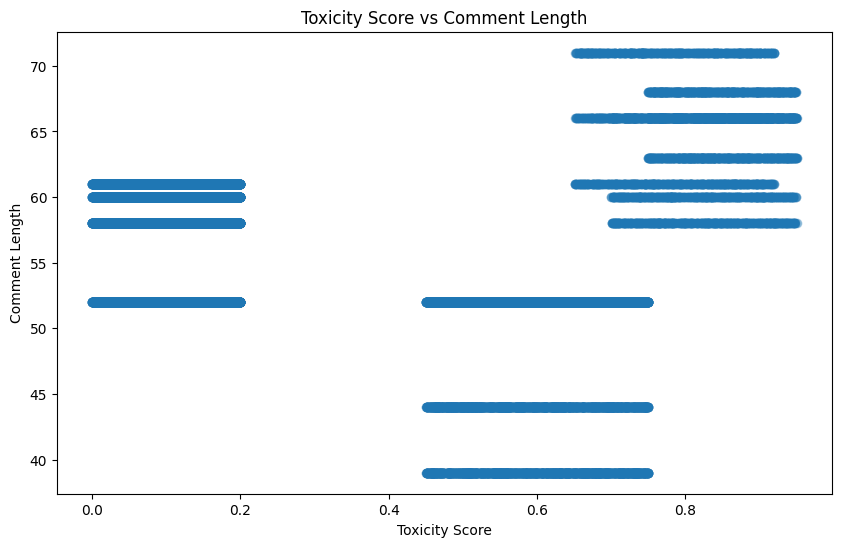

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df.Toxicity_Score, df.Comment_Length, alpha=.35)
plt.xlabel("Toxicity Score")
plt.ylabel("Comment Length")
plt.title("Toxicity Score vs Comment Length")
plt.show()


### ขั้นตอนที่ 2: Scatter Plot — Toxicity Score vs Word Count

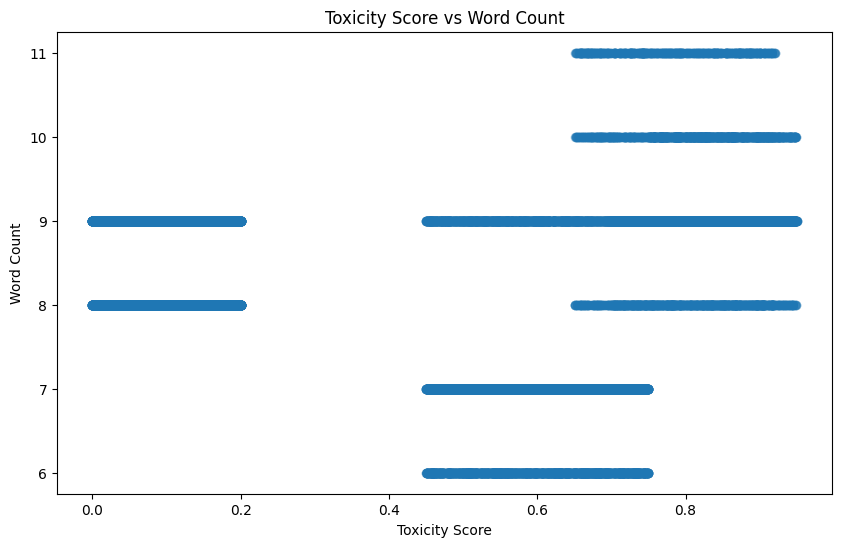

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df.Toxicity_Score, df.Word_Count, alpha=.35)
plt.xlabel("Toxicity Score")
plt.ylabel("Word Count")
plt.title("Toxicity Score vs Word Count")
plt.show()


### ขั้นตอนที่ 3: Histogram ของ Toxicity Score

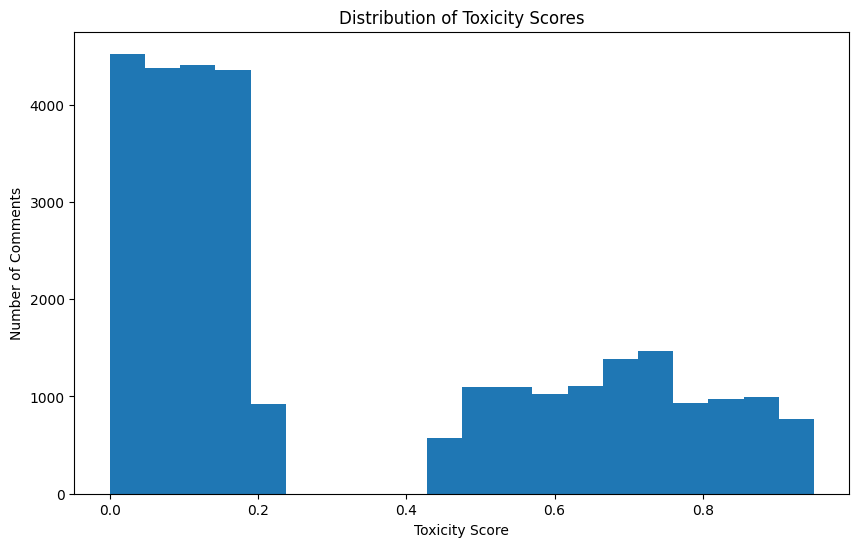

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(df.Toxicity_Score, bins=20)
plt.xlabel("Toxicity Score")
plt.ylabel("Number of Comments")
plt.title("Distribution of Toxicity Scores")
plt.show()


### ขั้นตอนที่ 4: Box Plot ของ Toxicity Score

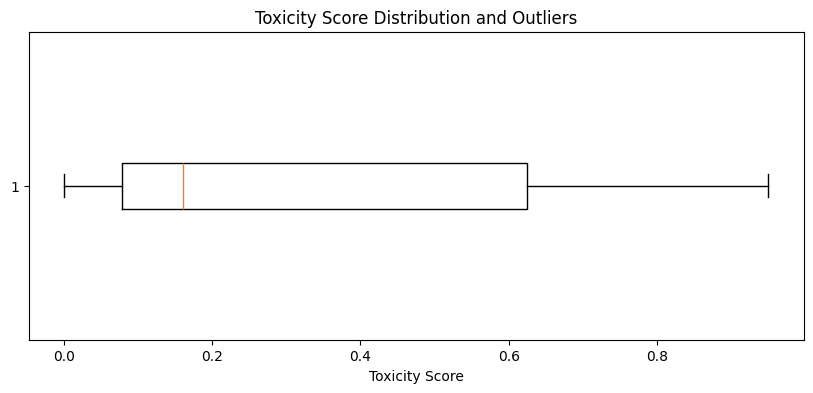

In [ ]:
plt.figure(figsize=(10,4))
plt.boxplot(df.Toxicity_Score, vert=False)
plt.xlabel("Toxicity Score")
plt.title("Toxicity Score Distribution and Outliers")
plt.show()


### ขั้นตอนที่ 5: Average Toxicity Score by Platform

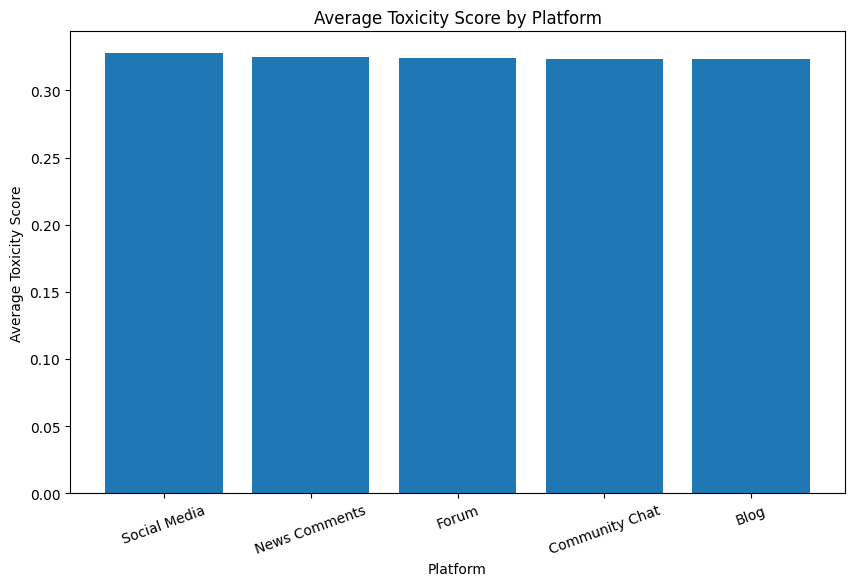

In [ ]:
platform_plot = df.groupby("Platform").Toxicity_Score.mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.bar(platform_plot.index, platform_plot.values)
plt.xlabel("Platform")
plt.ylabel("Average Toxicity Score")
plt.title("Average Toxicity Score by Platform")
plt.xticks(rotation=20)
plt.show()


### ขั้นตอนที่ 6: Average Toxicity Score by Topic

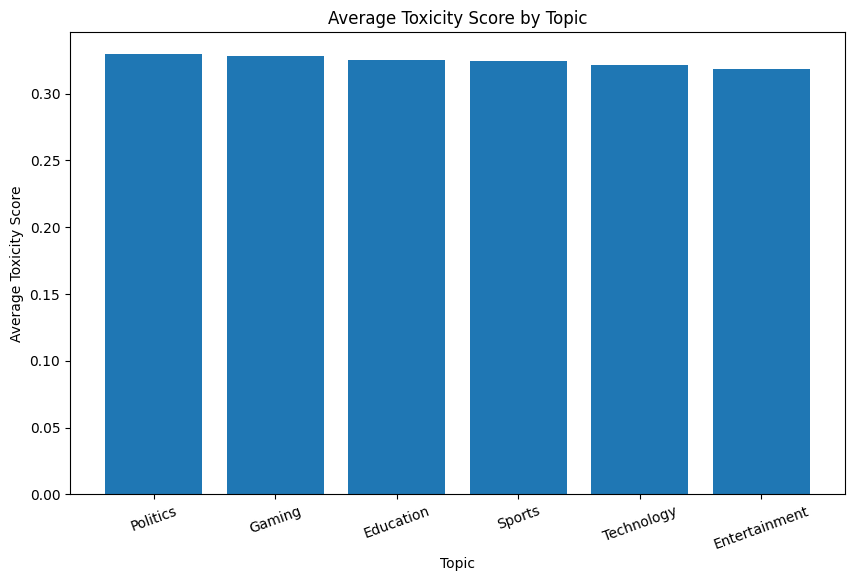

In [ ]:
topic_plot = df.groupby("Topic").Toxicity_Score.mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.bar(topic_plot.index, topic_plot.values)
plt.xlabel("Topic")
plt.ylabel("Average Toxicity Score")
plt.title("Average Toxicity Score by Topic")
plt.xticks(rotation=20)
plt.show()


### ขั้นตอนที่ 7: จำนวนความคิดเห็นตาม Toxicity Label

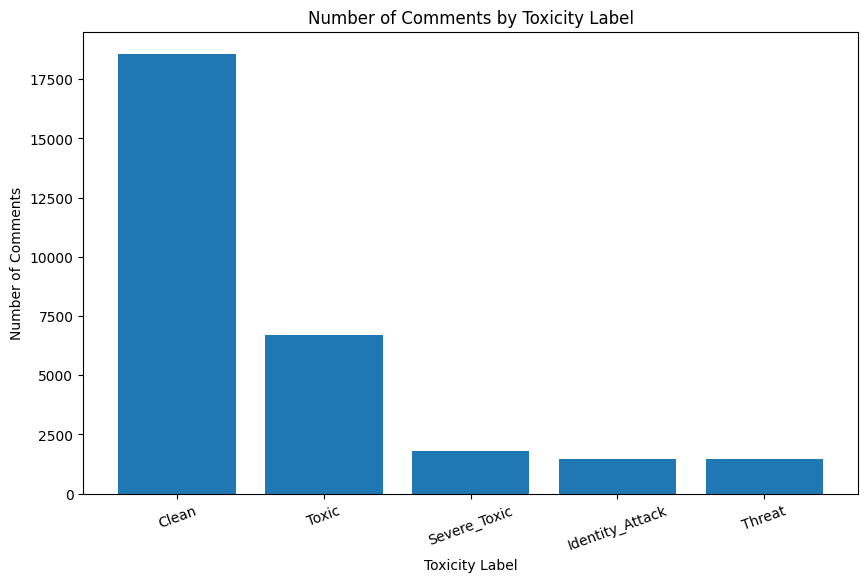

In [ ]:
label_counts = df.Toxicity_Label.value_counts()
plt.figure(figsize=(10,6))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Toxicity Label")
plt.ylabel("Number of Comments")
plt.title("Number of Comments by Toxicity Label")
plt.xticks(rotation=20)
plt.show()


### ขั้นตอนที่ 8: ตารางสรุปข้อค้นพบ (Findings Summary)

In [ ]:
findings_summary = pd.DataFrame({
    "Metric": ["จำนวนความคิดเห็น","Mean Toxicity Score","Median Toxicity Score","Pearson r: Score vs Length","Spearman rho: Score vs Length","Pearson r: Score vs Word Count","Spearman rho: Score vs Word Count","IQR Outliers","Score >= 0.80"],
    "Value": [len(df), df.Toxicity_Score.mean(), df.Toxicity_Score.median(), pearson_score_length, spearman_score_length, pearson_score_words, spearman_score_words, len(outliers), len(high_toxicity)]
})
findings_summary["Value"] = findings_summary["Value"].round(4)
display(findings_summary)


,Metric,Value
0,จำนวนความคิดเห็น,30000.0000
1,Mean Toxicity Score,0.3245
2,Median Toxicity Score,0.1610
3,Pearson r: Score vs Length,-0.0685
4,Spearman rho: Score vs Length,0.0038
5,Pearson r: Score vs Word Count,-0.0608
6,Spearman rho: Score vs Word Count,-0.0237
7,IQR Outliers,0.0000
8,Score >= 0.80,2885.0000


## ผลการวิเคราะห์และข้อค้นพบเชิงลึก (Findings & Insights)

จากข้อมูล **30,000 รายการ** สรุปได้ดังนี้

### Dataset Overview
* Mean Toxicity Score = **0.325** และ Median = **0.161**
* Mean Comment Length = **56.36** ตัวอักษร และ Mean Word Count = **8.34** คำ

### RQ1: ความสัมพันธ์
* Pearson ระหว่าง Score กับ Length = **-0.0685** และ Spearman = **0.0038**
* Pearson ระหว่าง Score กับ Word Count = **-0.0608** และ Spearman = **-0.0237**

ค่าความสัมพันธ์โดยรวมอยู่ในระดับต่ำ จึงไม่ควรสรุปว่าความคิดเห็นที่ยาวกว่าจะมีความเป็นพิษสูงกว่าเสมอไป และ Correlation ไม่ได้ยืนยันเหตุและผล

### RQ2: ความแตกต่างตามกลุ่ม
* Platform ที่มีค่าเฉลี่ยสูงสุดคือ **Social Media (0.327)** และต่ำสุดคือ **Blog (0.323)**
* Topic ที่มีค่าเฉลี่ยสูงสุดคือ **Politics (0.330)** และต่ำสุดคือ **Entertainment (0.318)**
* Toxicity Label ที่มีค่าเฉลี่ยสูงสุดคือ **Severe_Toxic (0.849)**

ข้อค้นพบเหล่านี้สะท้อนเฉพาะ Dataset ที่ศึกษา ไม่ควรนำไปเหมารวมกับผู้ใช้งานหรือแพลตฟอร์มจริงทั้งหมด

### RQ3: Distribution & Outliers
* Q1 = **0.079**, Q3 = **0.624**, IQR = **0.545**
* พบ Outliers ตามเกณฑ์ IQR จำนวน **0 รายการ**
* พบคะแนน `Toxicity_Score >= 0.80` จำนวน **2,885 รายการ** หรือประมาณ **9.62%**


## บทสรุปผลการวิเคราะห์ (Conclusion)

โครงงานนี้วิเคราะห์ความคิดเห็น **30,000 รายการ** โดยใช้ Toxicity Score เป็นตัวแปรหลัก ผลการวิเคราะห์พบว่าความสัมพันธ์ระหว่าง Toxicity Score กับความยาวและจำนวนคำอยู่ในระดับต่ำ ขณะที่การแบ่งกลุ่มตาม Platform, Topic และ Toxicity Label ทำให้เห็นความแตกต่างของค่าเฉลี่ยคะแนนภายใน Dataset ได้ชัดเจนกว่า

สำหรับการกระจายตัวของ Toxicity Score พบว่าเกณฑ์ IQR ให้จำนวน Outliers เท่ากับ **0 รายการ** และมีความคิดเห็นคะแนนสูงตั้งแต่ 0.80 ขึ้นไปจำนวน **2,885 รายการ**

**หมายเหตุ:** ผลทั้งหมดเป็นข้อค้นพบจาก Dataset ที่ศึกษา ไม่ใช่ข้อสรุปเชิงเหตุและผล และไม่ควรนำไปแทนข้อมูลของประชากรหรือแพลตฟอร์มทั้งหมด